# Caso Práctico: Neurona de McCulloch y Pitts
### Diagnóstico de Cáncer de Mama — Wisconsin Dataset

---
En este notebook vamos a construir una **Neurona de McCulloch-Pitts (MPNeuron)** para predecir si un tumor de mama es **maligno o benigno**.

El flujo general es:
1. 📥 Cargar los datos desde internet (ucimlrepo)
2. 👀 Explorar y entender qué contienen
3. 🔥 Analizar correlaciones y elegir las mejores características
4. ✂️ Dividir en datos de entrenamiento y prueba
5. 🔢 Convertir los números a binario (0 o 1)
6. 🧠 Crear y entrenar la MPNeuron
7. 📊 Evaluar qué tan bien predice

## Paso 1 — Cargar el dataset desde UCI

En lugar de usar el dataset que viene incluido en sklearn, vamos a descargarlo directamente desde la fuente oficial: el **UCI Machine Learning Repository**.

### ¿Por qué UCI y no sklearn?
- UCI es la fuente **original** del dataset (donado en 1995).
- No necesitamos guardar ningún archivo en nuestro proyecto.
- Al subir a GitHub, el código simplemente lo descarga solo cuando se ejecuta.
- Es buena práctica aprender a importar datos desde fuentes externas.

### ¿Qué es el `id=17`?
Cada dataset en UCI tiene un número de identificación único. El **17** corresponde al Breast Cancer Wisconsin (Diagnostic). Es como el ISBN de un libro — simplemente identifica cuál queremos.

In [1]:
# Primero instalamos las librerías si no las tenemos
# (solo necesitas correr esto una vez, después puedes comentarlo)
# !pip install ucimlrepo seaborn

from ucimlrepo import fetch_ucirepo

# Descargamos el dataset con su ID oficial
breast_cancer = fetch_ucirepo(id=17)

print("Dataset cargado correctamente")

Dataset cargado correctamente


## Paso 2 — Separar las características (X) y las etiquetas (Y)

En machine learning siempre tenemos dos cosas:
- **X** = las *entradas* del modelo (lo que le damos para que analice)
- **Y** = la *respuesta correcta* que queremos que aprenda a predecir

Analogía: imagínate que le enseñas a alguien a diagnosticar tumores. Le muestras fotos de células (**X**) y le dices si cada caso resultó maligno o benigno (**Y**). El modelo aprende la relación entre ambos.

In [2]:
import pandas as pd
import numpy as np

# X = las 30 medidas de las células (ya viene como DataFrame de pandas)
X = breast_cancer.data.features

# Y = el diagnóstico real: 'M' (Malignant/Maligno) o 'B' (Benign/Benigno)
Y_raw = breast_cancer.data.targets

print("Forma de X:", X.shape)   # (569 pacientes, 30 características)
print("Forma de Y:", Y_raw.shape)
print()
print("Primeros valores de Y:")
Y_raw.head()

Forma de X: (569, 30)
Forma de Y: (569, 1)

Primeros valores de Y:


,Diagnosis
0,M
1,M
2,M
3,M
4,M


## Paso 3 — Convertir Y de texto a números (0 y 1)

La MPNeuron no entiende texto. El dataset de UCI nos da `'M'` y `'B'`, necesitamos convertirlo a números.

- **0 = Maligno** (M) — el caso peligroso que queremos detectar
- **1 = Benigno** (B) — sin peligro

Lo importante es ser **consistentes** durante todo el proyecto.

In [4]:
# Convertimos 'M' a 0 (Maligno) y 'B' a 1 (Benigno)
Y = Y_raw['Diagnosis'].map({'M': 0, 'B': 1}).to_numpy()

print("Y después de convertir (primeros 20):")
print(Y[:20])
print()
print("Distribucion de casos:")
valores, conteos = np.unique(Y, return_counts=True)
for v, c in zip(valores, conteos):
    nombre = 'Maligno' if v == 0 else 'Benigno'
    print(f"  {nombre} ({v}): {c} casos ({c/len(Y)*100:.1f}%)")

Y después de convertir (primeros 20):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]

Distribucion de casos:
  Maligno (0): 212 casos (37.3%)
  Benigno (1): 357 casos (62.7%)


## Paso 4 — Explorar los datos (EDA)

Antes de entrenar cualquier modelo, es **obligatorio** entender qué datos tenemos. Esto se llama **Análisis Exploratorio de Datos (EDA)**.

Las 30 características son medidas de imágenes de células del tumor:
- 10 medidas: radio, textura, perímetro, área, suavidad, compacidad, concavidad, simetría...
- Cada medida tiene 3 versiones: **mean** (promedio), **se** (error estándar), **worst** (peor valor)
- 10 × 3 = **30 características**

In [5]:
# Ver las primeras filas como tabla
# En VSCode con Jupyter esto se muestra como tabla HTML interactiva
X.head()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
# Estadísticas básicas: min, max, promedio de cada columna
# Nos ayuda a entender el rango de valores antes de binarizar
X.describe()

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## Paso 5 — Análisis de Correlación y Mapa de Calor

### ¿Por qué no usar todas las columnas?
No todas las características son igual de útiles. Algunas tienen mucha relación con el diagnóstico, otras casi ninguna. Usar características que no aportan solo agrega **ruido** al modelo.

### ¿Qué es la correlación?
Un número entre -1 y +1 que mide qué tan relacionadas están dos variables:
- **+1** → cuando una sube, la otra también (relación perfecta positiva)
- **0**  → sin relación, son independientes
- **-1** → cuando una sube, la otra baja (relación perfecta negativa)

Queremos características con correlación **alta** (cerca de +1 o -1) respecto al diagnóstico.

### El mapa de calor
Es una tabla donde cada celda muestra la correlación entre dos variables, representada con color:
- **Rojo/cálido** → correlación alta (característica útil)
- **Azul/frío** → correlación negativa
- **Blanco/neutro** → sin correlación (característica poco útil)

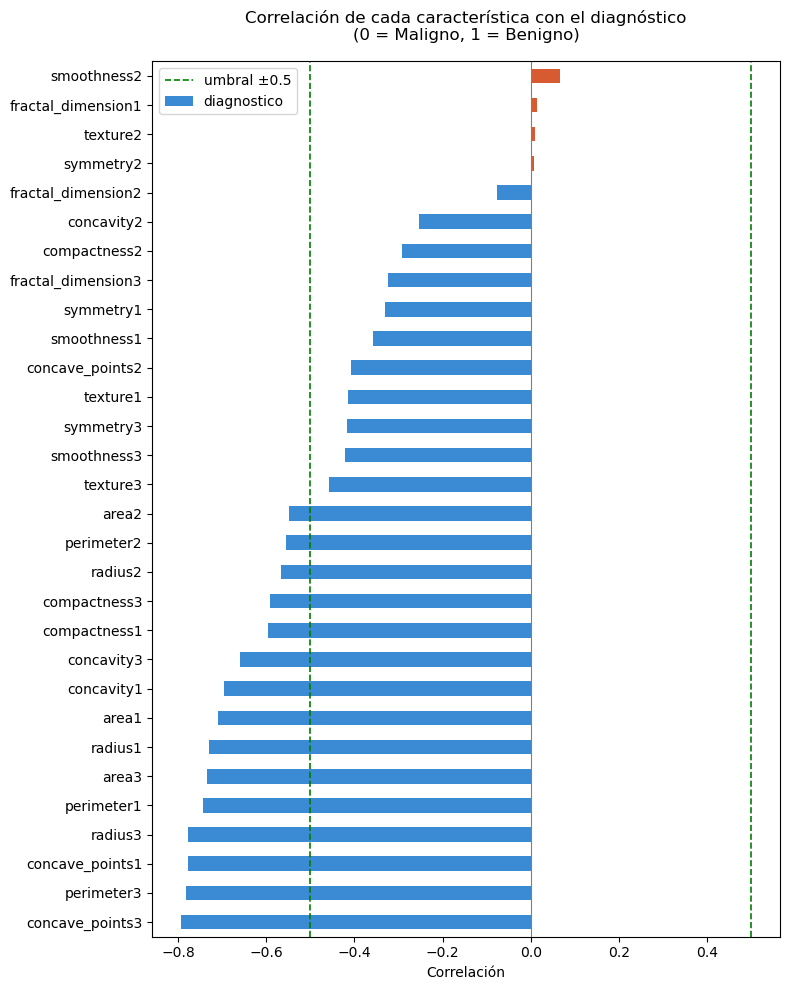

Las 5 características MÁS correlacionadas con el diagnóstico:
concave_points3    0.793566
perimeter3         0.782914
concave_points1    0.776614
radius3            0.776454
perimeter1         0.742636


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------
# Gráfica 1: Correlación de cada característica con el DIAGNÓSTICO
# Esto nos dice directamente cuáles características son más informativas
# -----------------------------------------------------------------------

# Pegamos X y Y en un solo DataFrame para poder calcular correlaciones
df_completo = X.copy()
df_completo['diagnostico'] = Y

# Correlación de cada columna con el diagnóstico (ordenada de menor a mayor)
correlacion_con_Y = df_completo.corr()['diagnostico'].drop('diagnostico').sort_values()

# Barras horizontales (más legibles con muchas variables)
fig, ax = plt.subplots(figsize=(8, 10))
colors = ['#3B8BD4' if v < 0 else '#D85A30' for v in correlacion_con_Y]
correlacion_con_Y.plot(kind='barh', ax=ax, color=colors, edgecolor='none')

# Líneas de referencia para ver el umbral de 0.5
ax.axvline(x=0,    color='gray',  linewidth=0.8)
ax.axvline(x=0.5,  color='green', linewidth=1.2, linestyle='--', label='umbral ±0.5')
ax.axvline(x=-0.5, color='green', linewidth=1.2, linestyle='--')

ax.set_title('Correlación de cada característica con el diagnóstico\n(0 = Maligno, 1 = Benigno)', pad=15)
ax.set_xlabel('Correlación')
ax.legend()
plt.tight_layout()
plt.show()

print("Las 5 características MÁS correlacionadas con el diagnóstico:")
print(correlacion_con_Y.abs().sort_values(ascending=False).head(5).to_string())

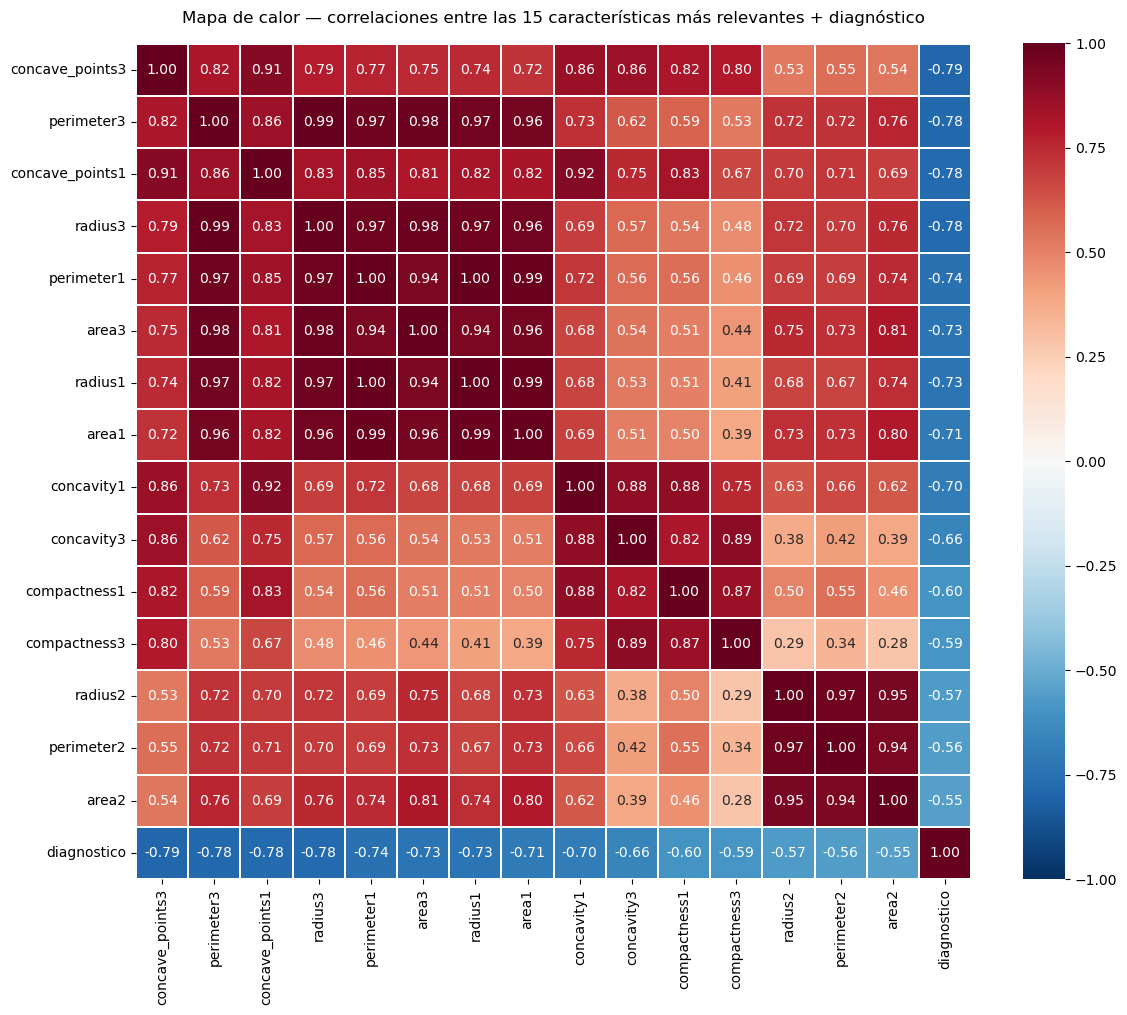

In [8]:
# -----------------------------------------------------------------------
# Gráfica 2: Mapa de calor de correlaciones ENTRE características
# Esto nos ayuda a ver cuáles son REDUNDANTES entre sí.
# Si dos características tienen correlación 1.0 entre ellas, dicen lo mismo
# y podemos quedarnos solo con una.
# -----------------------------------------------------------------------

# Usamos las 15 más correlacionadas con el diagnóstico para que el mapa sea legible
top15 = correlacion_con_Y.abs().sort_values(ascending=False).head(15).index.tolist()
df_top15 = X[top15].copy()
df_top15['diagnostico'] = Y

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df_top15.corr(),
    annot=True,       # Muestra el número dentro de cada celda
    fmt='.2f',        # Formato: 2 decimales
    cmap='RdBu_r',    # Paleta: rojo (alto) a azul (bajo)
    vmin=-1, vmax=1,  # Escala fija de -1 a 1
    square=True,      # Celdas cuadradas
    linewidths=0.3,
    ax=ax
)
ax.set_title('Mapa de calor — correlaciones entre las 15 características más relevantes + diagnóstico', pad=15)
plt.tight_layout()
plt.show()

## Paso 6 — Selección de características

### ¿Cómo decidimos qué características conservar?
Usamos la correlación con el diagnóstico:
- Si la correlación (en valor absoluto) es **mayor a 0.5** → la característica es informativa → la **conservamos**
- Si es **menor a 0.5** → aporta poco → la **descartamos**

El umbral de 0.5 es una decisión razonable pero no absoluta. Podrías probar con 0.4 o 0.6 y ver cómo cambia el accuracy del modelo.

In [34]:
# Elegimos el umbral de correlación
umbral = 0.4

# Filtramos las características con correlación mayor al umbral
features_seleccionadas = correlacion_con_Y[correlacion_con_Y.abs() >= umbral].index.tolist()

print(f"Características seleccionadas (correlación >= {umbral} con el diagnóstico):")
for feat in features_seleccionadas:
    print(f"  {feat:<35} {correlacion_con_Y[feat]:+.4f}")

print(f"\nTotal: {len(features_seleccionadas)} de 30 características conservadas")

# Creamos un X reducido con solo las características útiles
X_reducido = X[features_seleccionadas]
print(f"Nueva forma de X: {X_reducido.shape}")

Características seleccionadas (correlación >= 0.4 con el diagnóstico):
  concave_points3                     -0.7936
  perimeter3                          -0.7829
  concave_points1                     -0.7766
  radius3                             -0.7765
  perimeter1                          -0.7426
  area3                               -0.7338
  radius1                             -0.7300
  area1                               -0.7090
  concavity1                          -0.6964
  concavity3                          -0.6596
  compactness1                        -0.5965
  compactness3                        -0.5910
  radius2                             -0.5671
  perimeter2                          -0.5561
  area2                               -0.5482
  texture3                            -0.4569
  smoothness3                         -0.4215
  symmetry3                           -0.4163
  texture1                            -0.4152
  concave_points2                     -0.4080

Total: 2

## Paso 7 — Dividir en Train y Test

Imagínate que estudias para un examen con exactamente las mismas preguntas que van a caer. Claro que sacas 10, pero eso no demuestra que aprendiste.

Lo mismo con los modelos: necesitamos evaluarlos con datos que nunca vieron durante el entrenamiento.

- **X_train / y_train** → el modelo aprende con estos (75% ≈ 426 pacientes)
- **X_test / y_test** → evaluamos con estos, que nunca vio (25% ≈ 143 pacientes)

- `stratify=Y` → mantiene la misma proporción maligno/benigno en ambas partes
- `random_state=42` → fija la aleatoriedad para que la división sea reproducible

In [35]:
from sklearn.model_selection import train_test_split

# Dividimos usando X_reducido (solo las características relevantes)
X_train, X_test, y_train, y_test = train_test_split(
    X_reducido,
    Y,
    stratify=Y,
    random_state=42
)

print(f"Datos de entrenamiento: {len(X_train)} pacientes, {X_train.shape[1]} características")
print(f"Datos de prueba:        {len(X_test)} pacientes, {X_test.shape[1]} características")
print()
print(f"Proporción maligno/benigno en train: {(y_train==0).sum()}/{(y_train==1).sum()}")
print(f"Proporción maligno/benigno en test:  {(y_test==0).sum()}/{(y_test==1).sum()}")

Datos de entrenamiento: 426 pacientes, 20 características
Datos de prueba:        143 pacientes, 20 características

Proporción maligno/benigno en train: 159/267
Proporción maligno/benigno en test:  53/90


## Paso 8 — Binarización (convertir números continuos a 0 o 1)

La MPNeuron solo puede procesar entradas binarias (0 o 1), pero nuestros datos tienen valores como `17.99`, `122.8`, `0.1184`...

`pd.cut(columna, bins=2, labels=[0,1])` divide cada columna en 2 grupos iguales:
- Valores en la mitad inferior → `0`
- Valores en la mitad superior → `1`

Aplicamos train y test **por separado** para no contaminar el test con información del train.

In [36]:
# Binarizamos: cada columna queda como 0 o 1
X_train_bin = X_train.apply(pd.cut, bins=2, labels=[0, 1])
X_test_bin  = X_test.apply(pd.cut,  bins=2, labels=[0, 1])

print("Antes (primeros 3 valores de la primera columna):")
print(X_train.iloc[:3, 0].values)
print()
print("Después de binarizar:")
print(X_train_bin.iloc[:3, 0].values)
print()
print(f"Forma final de X_train_bin: {X_train_bin.shape}")

Antes (primeros 3 valores de la primera columna):
[0.1613  0.05366 0.255  ]

Después de binarizar:
[1, 0, 1]
Categories (2, int64): [0 < 1]

Forma final de X_train_bin: (426, 20)


## Paso 9 — La clase MPNeuron

La Neurona de McCulloch-Pitts (1943) es el modelo más simple de neurona artificial:
1. Recibe entradas binarias (0 o 1)
2. Las **suma**
3. Si la suma **>= threshold** → predice 1 (benigno)
4. Si la suma **< threshold** → predice 0 (maligno)

El método `fit()` prueba todos los thresholds posibles con fuerza bruta y elige el mejor.

In [37]:
from sklearn.metrics import accuracy_score

class MPNeuron:
    def __init__(self):
        self.threshold = None

    def model(self, x):
        """Suma las entradas binarias y compara con el threshold."""
        z = sum(x)
        return z >= self.threshold  # True = benigno, False = maligno

    def predic(self, X):
        """Aplica model() a cada paciente."""
        return np.array([self.model(x) for x in X])

    def fit(self, X, Y):
        """Encuentra el threshold óptimo probando todos los valores posibles."""
        accuracy = {}
        for th in range(X.shape[1] + 1):  # 0, 1, 2, ... hasta N características
            self.threshold = th
            Y_pred = self.predic(X)
            accuracy[th] = accuracy_score(Y_pred, Y)

        self.threshold = max(accuracy, key=accuracy.get)

        print("Accuracy por threshold:")
        for th, acc in accuracy.items():
            marca = " <- OPTIMO" if th == self.threshold else ""
            print(f"  Threshold {th:2d}: {acc:.4f}{marca}")

print("Clase MPNeuron definida")

Clase MPNeuron definida


## Paso 10 — Entrenar el modelo

Le pasamos los datos de **entrenamiento** binarizados con sus etiquetas correctas.
El modelo probará cada threshold y se quedará con el que da mejor accuracy en entrenamiento.

In [40]:
mp_neurona = MPNeuron()

# Entrenamos con los datos de ENTRENAMIENTO (X_train_bin) y sus etiquetas (y_train)
mp_neurona.fit(X_train_bin.to_numpy(), y_train)

print(f"\nThreshold optimo seleccionado: {mp_neurona.threshold}")

Accuracy por threshold:
  Threshold  0: 0.6268 <- OPTIMO
  Threshold  1: 0.1972
  Threshold  2: 0.1315
  Threshold  3: 0.1291
  Threshold  4: 0.1549
  Threshold  5: 0.1761
  Threshold  6: 0.1972
  Threshold  7: 0.2300
  Threshold  8: 0.2606
  Threshold  9: 0.3005
  Threshold 10: 0.3216
  Threshold 11: 0.3357
  Threshold 12: 0.3427
  Threshold 13: 0.3545
  Threshold 14: 0.3662
  Threshold 15: 0.3709
  Threshold 16: 0.3732
  Threshold 17: 0.3732
  Threshold 18: 0.3732
  Threshold 19: 0.3732
  Threshold 20: 0.3732

Threshold optimo seleccionado: 0


## Paso 11 — Predicciones y evaluación

Evaluamos con los datos de **prueba** — que el modelo nunca vio durante el entrenamiento.

**Accuracy** = casos correctos / total de casos

**Matriz de confusión** — nos dice dónde fallamos:
- TN: predijo maligno, era maligno ✅
- TP: predijo benigno, era benigno ✅
- FP: predijo benigno, pero era maligno ❌ (el más peligroso en medicina)
- FN: predijo maligno, pero era benigno ❌

In [41]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Predecimos sobre datos de PRUEBA
Y_Pred = mp_neurona.predic(X_test_bin.to_numpy())

acc = accuracy_score(y_test, Y_Pred)
print(f"Accuracy del modelo: {acc:.4f} ({acc*100:.1f}%)")
print()

cm = confusion_matrix(y_test, Y_Pred)
TN, FP, FN, TP = cm.ravel()
print(f"  Malignos correctamente identificados (TN): {TN}")
print(f"  Benignos correctamente identificados  (TP): {TP}")
print(f"  Malignos diagnosticados como benignos  (FP): {FP}  <- PELIGROSO")
print(f"  Benignos diagnosticados como malignos  (FN): {FN}")

Accuracy del modelo: 0.6294 (62.9%)

  Malignos correctamente identificados (TN): 0
  Benignos correctamente identificados  (TP): 90
  Malignos diagnosticados como benignos  (FP): 53  <- PELIGROSO
  Benignos diagnosticados como malignos  (FN): 0


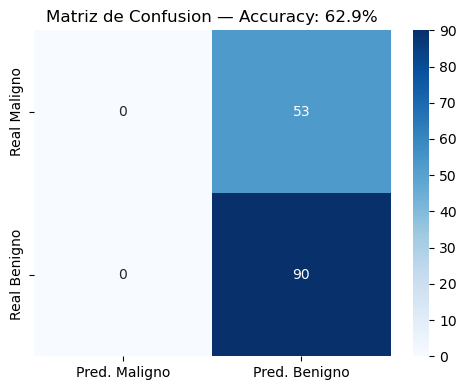

In [42]:
# Visualizar la matriz de confusión como mapa de calor
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=['Pred. Maligno', 'Pred. Benigno'],
    yticklabels=['Real Maligno', 'Real Benigno'],
    ax=ax
)
ax.set_title(f'Matriz de Confusion — Accuracy: {acc*100:.1f}%')
plt.tight_layout()
plt.show()

## Reflexión final

Al quedarnos solo con las características más correlacionadas eliminamos el **ruido** que confundía al modelo, lo que debería mejorar el accuracy.

La MPNeuron sigue siendo muy limitada:
- Trata todas las características por igual (sin pesos)
- Solo acepta valores binarios (perdemos información al binarizar)

En las siguientes clases veremos el **Perceptrón**, que introduce pesos para darle más importancia a algunas características. Toda red neuronal moderna es esencialmente muchas neuronas simples como esta, trabajando juntas.